# Bond Percolation: Dataset Generation, Visualization, Training & Benchmarking

This notebook demonstrates:
1. Generating graphs via a constant graphon and performing bond percolation.
2. Visualizing the component-size distribution.
3. Training a GCN to predict each node’s component size.
4. Benchmarking regression RMSE and node‐classification accuracy.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data, DataLoader
from logic.graphon_generator import generate_constant_graphon, interp_graphon, sample_graph
from simulator.percolation_simulator import simulate_bond_percolation
from model.models import PercGCN
import torch.nn.functional as F
from sklearn.metrics import mean_squared_error, accuracy_score
import networkx as nx

## 1. Dataset Preparation
Sample graphs, percolate, and record true component sizes.

In [3]:
# Parameters
num_graphs = 200
num_nodes = 50
p = 0.1  # percolation probability
# Build graphon
W = generate_constant_graphon(p=0.1, resolution=200)
graphon_fn = interp_graphon(W)
# Create dataset list
dataset = []
for _ in range(num_graphs):
    G = sample_graph(graphon_fn, num_nodes)
    Gp = simulate_bond_percolation(G, p)
    A = nx.to_numpy_array(Gp, nodelist=range(num_nodes))
    comps = list(nx.connected_components(Gp))
    sizes = np.zeros(num_nodes, dtype=int)
    for comp in comps:
        for node in comp:
            sizes[node] = len(comp)
    edge_index = torch.tensor(list(Gp.edges())).t().contiguous()
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
    data = Data(x=torch.ones((num_nodes,1)), edge_index=edge_index, y=torch.from_numpy(sizes).float())
    dataset.append(data)
# Split
split = int(0.8 * num_graphs)
train_set = dataset[:split]
val_set = dataset[split:]
train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = DataLoader(val_set, batch_size=16)


c:\Users\rapon\AppData\Local\Programs\Python\Python39\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


## 2. Visualization
Plot histogram of component sizes in one sample graph.

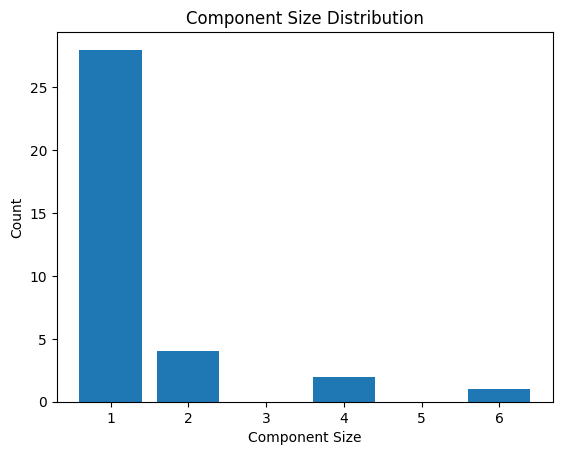

In [4]:
# Sample one graph
G = sample_graph(graphon_fn, num_nodes)
Gp = simulate_bond_percolation(G, p)
comps = list(nx.connected_components(Gp))
sizes = [len(c) for c in comps]
plt.hist(sizes, bins=range(1, max(sizes)+2), align='left', rwidth=0.8)
plt.xlabel('Component Size')
plt.ylabel('Count')
plt.title('Component Size Distribution')
plt.show()

## 3. Model & Training

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PercGCN(in_channels=1, hidden_channels=32, num_layers=3, dropout=0.1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 60
train_losses, val_losses = [], []
for epoch in range(1, epochs+1):
    model.train()
    epoch_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index)
        loss = F.mse_loss(out, batch.y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss/len(train_loader))
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            val_loss += F.mse_loss(model(batch.x, batch.edge_index), batch.y).item()
    val_losses.append(val_loss/len(val_loader))
    print(f'Epoch {epoch:02d} | Train MSE: {train_losses[-1]:.4f} | Val MSE: {val_losses[-1]:.4f}')


Epoch 01 | Train MSE: 4.8009 | Val MSE: 2.9297
Epoch 02 | Train MSE: 3.9550 | Val MSE: 2.2947
Epoch 03 | Train MSE: 3.3101 | Val MSE: 1.8889
Epoch 04 | Train MSE: 2.9020 | Val MSE: 1.7501
Epoch 05 | Train MSE: 2.7745 | Val MSE: 1.7907
Epoch 06 | Train MSE: 2.7655 | Val MSE: 1.8179
Epoch 07 | Train MSE: 2.7594 | Val MSE: 1.7980
Epoch 08 | Train MSE: 2.7636 | Val MSE: 1.7727
Epoch 09 | Train MSE: 2.7648 | Val MSE: 1.7684
Epoch 10 | Train MSE: 2.7476 | Val MSE: 1.7736
Epoch 11 | Train MSE: 2.7556 | Val MSE: 1.7737
Epoch 12 | Train MSE: 2.7441 | Val MSE: 1.7795
Epoch 13 | Train MSE: 2.7580 | Val MSE: 1.7744
Epoch 14 | Train MSE: 2.7414 | Val MSE: 1.7730
Epoch 15 | Train MSE: 2.7444 | Val MSE: 1.7785
Epoch 16 | Train MSE: 2.7408 | Val MSE: 1.7744
Epoch 17 | Train MSE: 2.7431 | Val MSE: 1.7766
Epoch 18 | Train MSE: 2.7507 | Val MSE: 1.7783
Epoch 19 | Train MSE: 2.7382 | Val MSE: 1.7757
Epoch 20 | Train MSE: 2.7672 | Val MSE: 1.7729
Epoch 21 | Train MSE: 2.7464 | Val MSE: 1.7798
Epoch 22 | Tr

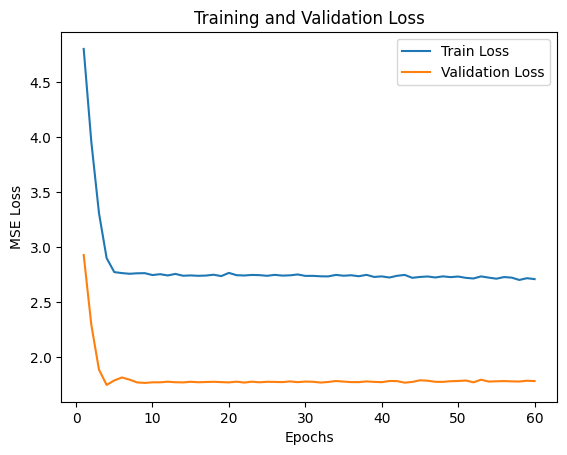

In [8]:
plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

## 4. Benchmark

- The RMSE shows that the model performs reasonably well in predicting component sizes but has room for improvement.
- The low classification accuracy suggests that the model may need further tuning or additional features to better distinguish nodes in the giant component.

In [9]:
# Regression RMSE on val set
model.eval()
y_trues, y_preds = [], []
with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        pred = model(batch.x, batch.edge_index).cpu().numpy()
        y_preds.append(pred)
        y_trues.append(batch.y.cpu().numpy())
    y_preds = np.concatenate(y_preds)
    y_trues = np.concatenate(y_trues)
rmse = np.sqrt(mean_squared_error(y_trues, y_preds))
print(f'Val RMSE: {rmse:.4f}')
# Classification accuracy: predicting if node is in giant component (size > median)
median = np.median(y_trues)
acc = accuracy_score(y_trues > median, y_preds > median)
print(f'Giant‐component accuracy: {acc:.4f}')


Val RMSE: 1.3539
Giant‐component accuracy: 0.3690
